In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import flax

In [3]:
do_64_bit = False
if do_64_bit: jax.config.update("jax_enable_x64", True)

In [40]:
import solve
import aux_ as aux
import RANK
import linear
import neural_nets
import model_funcs

# Device

In [5]:
device = aux.choose_gpu()

choosing cpu


# Load solutions

In [6]:
ZLB_sol_path = 'output/nn_ZLB_28_4.pkl'
noZLB_sol_path = 'output/nn_noZLB_28_4.pkl'

In [7]:
model = RANK.RANK_model(device)
model.load(ZLB_sol_path)

model_noZLB = RANK.RANK_model(device)
model_noZLB.load(noZLB_sol_path, opt_load=False)

# IRFs

In [8]:
shock_std = (0.0082, 0.0044, 0.0097)

#shock_std = (2*0.0082, 2*0.0044, 2*0.0097)


c:\Users\qxb650\GlobalRANK\RANK.py:432: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend()


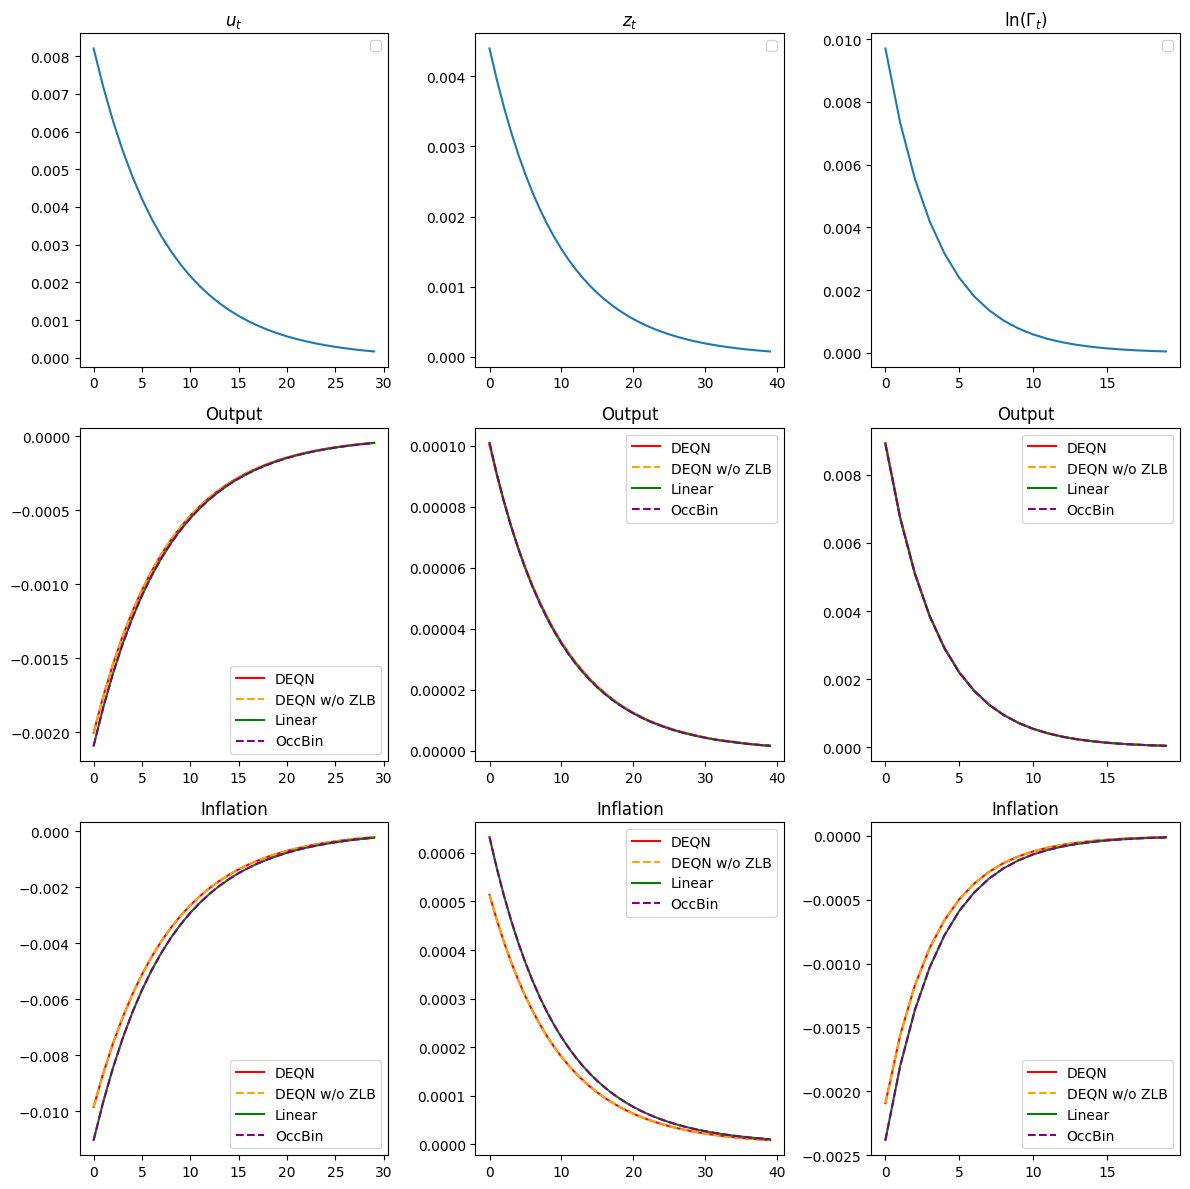

In [9]:
model.compute_IRF(shock_std, extra_nn=model_noZLB.nn)
model.plot_IRF(plot_extra=True, save_path='plots/IRFs.png')

# GIRFs

In [10]:
model.compute_GIRF(shock_std, 10000, extra_nn=model_noZLB.nn)

c:\Users\qxb650\GlobalRANK\RANK.py:513: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend()


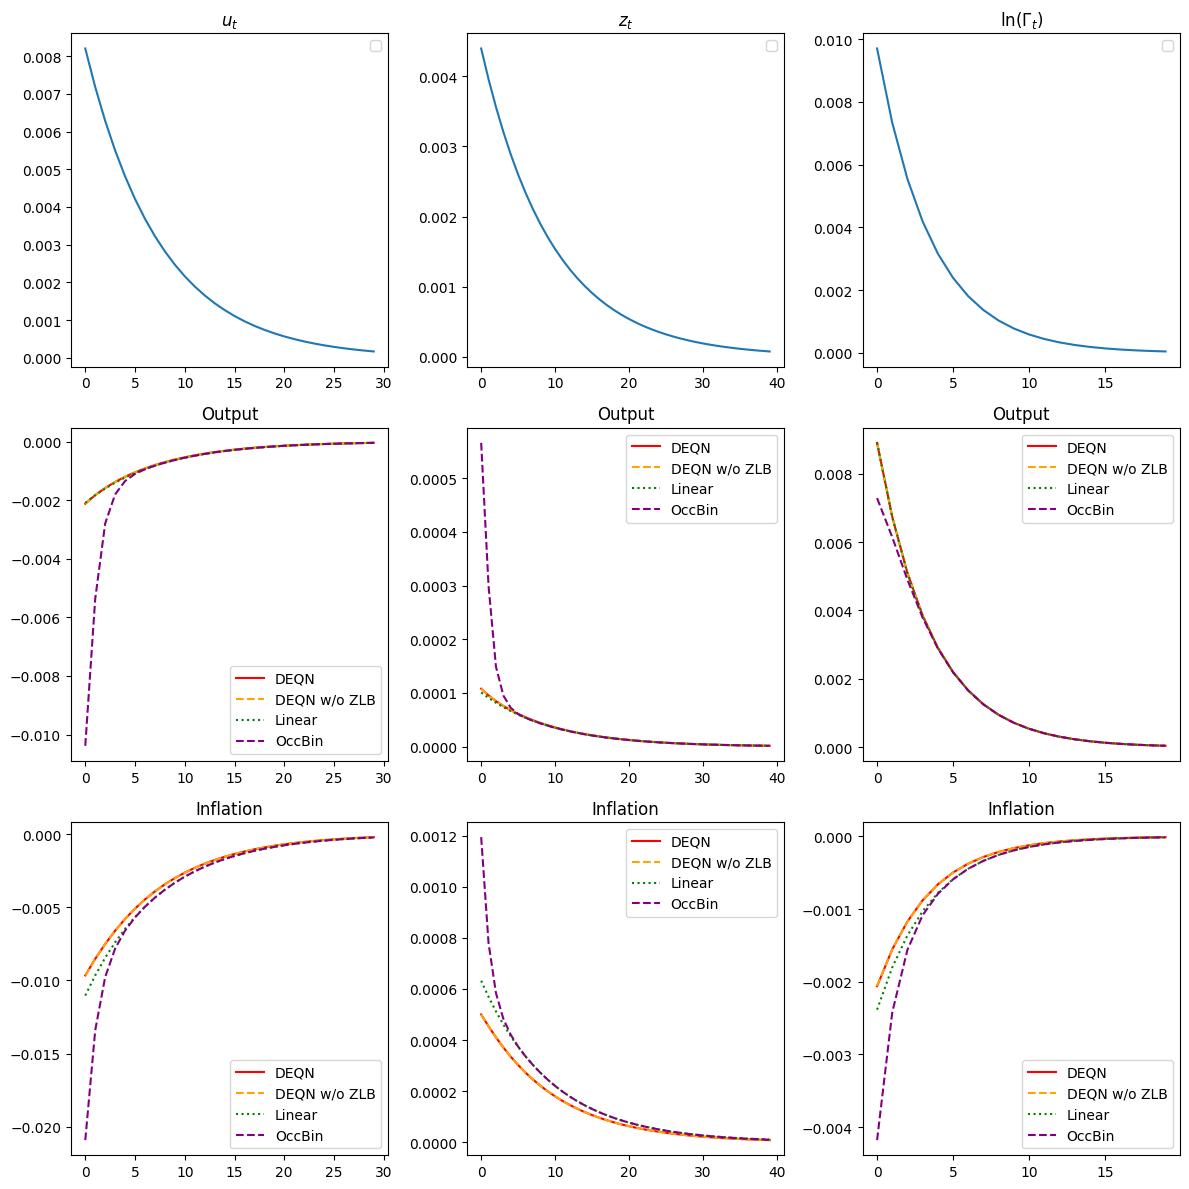

In [11]:
model.plot_GIRF(plot_extra=True, save_path='plots/GIRFs.png')

# Simulation ($N=1, T=70$)

In [12]:
solve.simulate(model, 70, (0.0082, 0.0044, 0.0097), extra_nn=model_noZLB.nn)

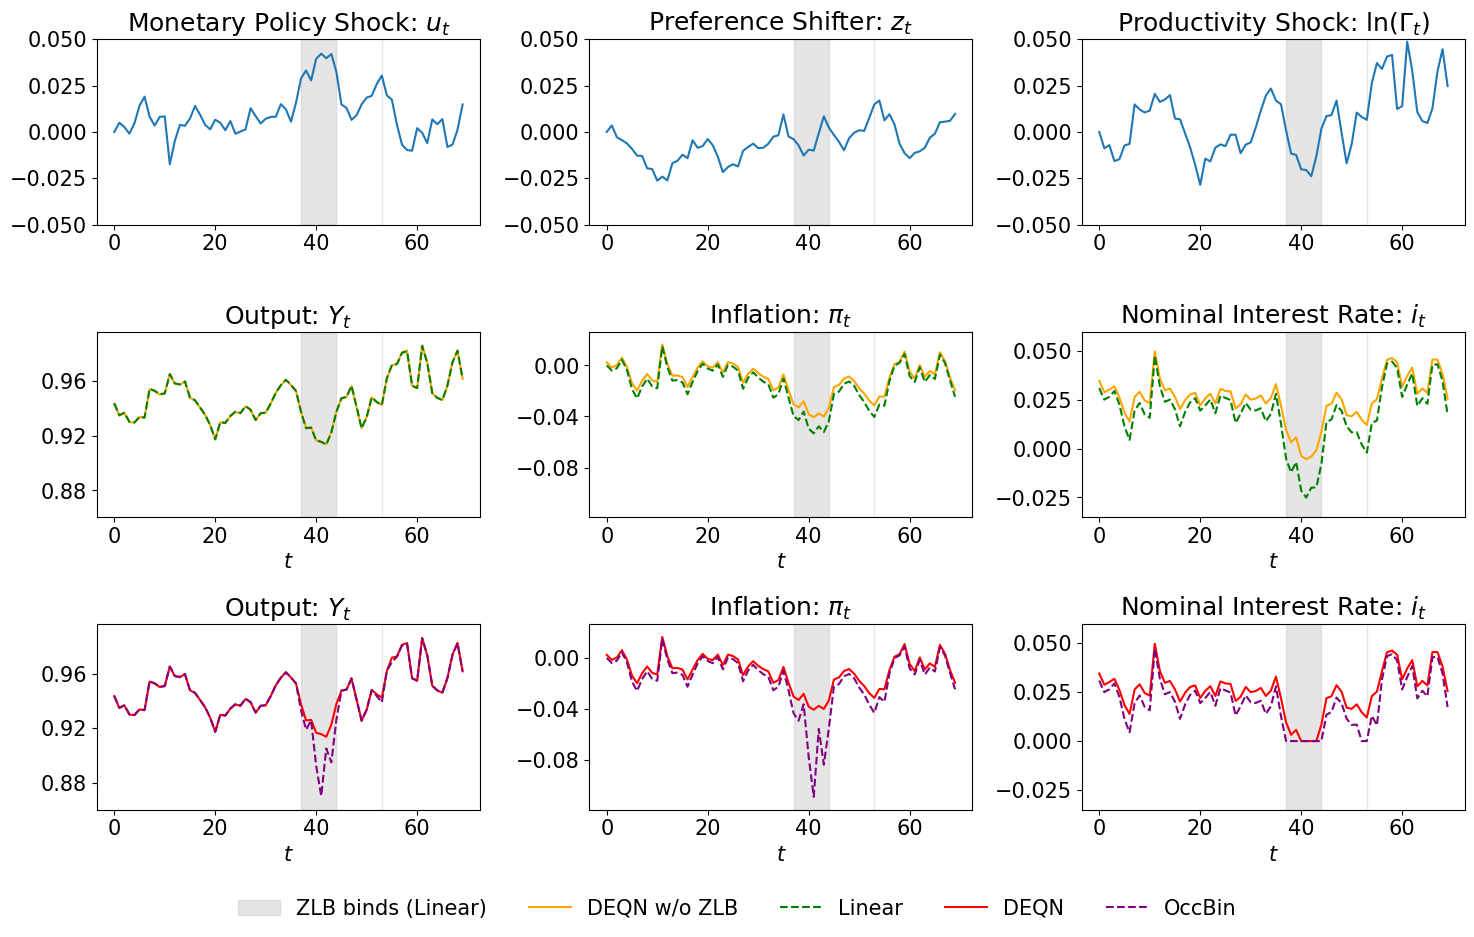

In [13]:
import matplotlib.ticker as mticker
plt.rcParams.update({'font.size': 15})

f, ax = plt.subplots(3,3, figsize=(15,10))

ax[0,0].plot(model.sim.states[:, 0])
ax[0,0].set_title(r'Monetary Policy Shock: $u_t$')

ax[0,1].plot(model.sim.states[:, 1])
ax[0,1].set_title(r'Preference Shifter: $z_t$')

ax[0,2].plot(model.sim.states[:, 2])
ax[0,2].set_title(r'Productivity Shock: $\ln(\Gamma_t)$')

for i in range(3):
    ax[0,i].set_ylim([-0.05, 0.05])

ax[1,0].plot(model.sim.Y_extra, label='DEQN w/o ZLB', color='orange')
ax[1,0].plot(model.sim.Y_lin, label='Linear', ls = '--', color='green')

ax[1,1].plot(model.sim.pi_extra, color='orange') #, label='DEQN w/o ZLB')
ax[1,1].plot(model.sim.pi_lin, ls='--', color='green') #, label='Linear', ls = '--')

ax[1,2].plot(model.sim.i_extra, color='orange') #, label='DEQN w/o ZLB')
ax[1,2].plot(model.sim.i_lin, ls='--', color='green') # label='Linear', ls = '--')

ax[2,0].plot(model.sim.Y, label='DEQN', color='red')
ax[2,0].plot(model.sim.Y_OccBin, label='OccBin', ls='--', color='purple')

ax[2,1].plot(model.sim.pi, color='red') #, label='DEQN')
ax[2,1].plot(model.sim.pi_OccBin, ls='--', color='purple') #, label='OccBin', ls='--')

ax[2,2].plot(model.sim.i, color='red') #, label='DEQN')
ax[2,2].plot(model.sim.i_OccBin, ls='--', color='purple') # label='OccBin', ls='--')

#
Ys_ = jnp.stack([model.sim.Y, model.sim.Y_lin, model.sim.Y_extra, model.sim.Y_OccBin])
pis_ = jnp.stack([model.sim.pi, model.sim.pi_lin, model.sim.pi_extra, model.sim.pi_OccBin])
is_ = jnp.stack([model.sim.i, model.sim.i_lin, model.sim.i_extra, model.sim.i_OccBin])

for i in range(1,3):
    ax[i,0].set_ylim([Ys_.min()-0.01, Ys_.max()+0.01])
    ax[i,1].set_ylim([pis_.min()-0.01, pis_.max()+0.01])
    ax[i,2].set_ylim([is_.min()-0.01, is_.max()+0.01])

#
for i in range(3):
    for j in range(1,3):
        ax[j,i].set_xlabel('$t$')

        ax[j,0].set_title(r'Output: $Y_t$')
        ax[j,1].set_title(r'Inflation: $\pi_t$')
        ax[j,2].set_title(r'Nominal Interest Rate: $i_t$')

zlb_mask = model.sim.i_lin < 0

label_add = True
for i in range(3):
    for j in range(3):
        
        if label_add:
            ax[i,j].fill_between(range(len(zlb_mask)), 
                             ax[i,j].get_ylim()[0], ax[i,j].get_ylim()[1], 
                             where=zlb_mask, 
                             color='gray', alpha=0.2, label='ZLB binds (Linear)')
            label_add = False

        else:
            ax[i,j].fill_between(range(len(zlb_mask)), 
                        ax[i,j].get_ylim()[0], ax[i,j].get_ylim()[1], 
                        where=zlb_mask, 
                        color='gray', alpha=0.2)

for i in range(3):
    for j in range(3):
        ax[i,j].yaxis.set_major_locator(mticker.MaxNLocator(nbins=4)) # nbins=4 giver præcis 5 ticks

# 1. Kør tight_layout FØRST, men lad 10% (0.1) være fri i bunden
f.tight_layout(rect=[0, 0.1, 1, 1])

# 2. Placer nu legenden i det frie område
f.legend(loc='lower center', 
         bbox_to_anchor=(0.5, 0.05), # 0.02 er lige over bunden i det tomme felt
         ncol=5,          
         frameon=False)

# Simulation ($N=10000, T=1$)

In [82]:
sigma_quad = {
    "sigma_eps_u" : 0.0082,
    "sigma_eps_z" : 0.0044,
    "sigma_eps_Gamma" : 0.0097
}


In [83]:
key = jax.random.key(42)

N = 100_000

states = aux.draw_states_directly(key, model.par, jnp.float32, N, sigma_quad["sigma_eps_u"], sigma_quad["sigma_eps_z"], sigma_quad["sigma_eps_Gamma"])

states = states[None, :, :]

linear.simulate_linear(model, sigma_quad, 1, N, known_states=states)

Y, pi = neural_nets.eval_nn(model.par, model.train, model.linear, model.nn, states[0], N)

Y_extra, pi_extra = neural_nets.eval_nn(model.par, model.train, model.linear, model_noZLB.nn, states[0], N)

i = model_funcs.taylor_rule(model.par, Y, pi, states[0, :, 0], states[0,:, 1], states[0,:, 2], 0.0, 0.0, 0.00, jnp.ones(1))

i_extra = model_funcs.taylor_rule(model.par, Y_extra, pi_extra, states[0, :, 0], states[0,:, 1], states[0,:, 2], 0.0, 0.0, -100, jnp.ones(1))

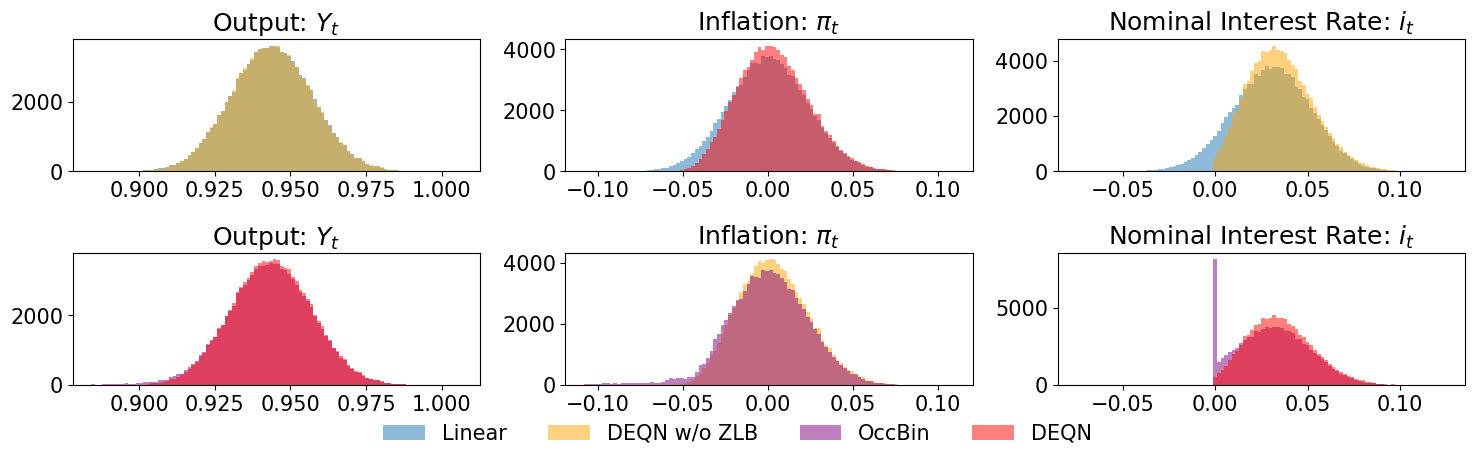

In [84]:
#maximum observations
data_max = max(model.sim.Y_OccBin.max(), model.sim.Y_lin.max())
sh_bins = np.linspace(model.sim.Y_lin.min(), data_max, 101)

f, ax = plt.subplots(2,3, figsize=(15,5))
ax[0,0].hist(model.sim.Y_lin.flatten(), bins=sh_bins, alpha=0.5, label='Linear')
ax[0,0].hist(Y_extra.flatten(), bins=sh_bins, alpha=0.5, label='DEQN w/o ZLB', color='orange')

ax[1,0].hist(model.sim.Y_OccBin.flatten(), bins=sh_bins, alpha=0.5, label='OccBin', color='purple')
ax[1,0].hist(Y.flatten(), bins=sh_bins, alpha=0.5, label='DEQN', color='red')

data_max = max(model.sim.pi_OccBin.max(), model.sim.pi_lin.max())
sh_bins = np.linspace(model.sim.pi_lin.min(), data_max, 101)

ax[0,1].hist(model.sim.pi_lin.flatten(), bins=sh_bins, alpha=0.5)
ax[1,1].hist(pi_extra.flatten(), bins=sh_bins, alpha=0.5, color='orange')

ax[1,1].hist(model.sim.pi_OccBin.flatten(), bins=sh_bins, alpha=0.5, color='purple')
ax[0,1].hist(pi.flatten(), bins=sh_bins, alpha=0.5, color='red')

data_max = max(model.sim.i_OccBin.max(), model.sim.i_lin.max())
sh_bins = np.linspace(model.sim.i_lin.min(), data_max, 101)

ax[0,2].hist(model.sim.i_lin.flatten(), bins=sh_bins, alpha=0.5)
ax[0,2].hist(i_extra.flatten(), bins=sh_bins, alpha=0.5, color='orange')

ax[1,2].hist(model.sim.i_OccBin.flatten(), bins=sh_bins, alpha=0.5, color='purple')
ax[1,2].hist(i.flatten(), bins=sh_bins, alpha=0.5, color='red')

for i_ in range(2):
    ax[i_,0].set_title(r'Output: $Y_t$')
    ax[i_,1].set_title(r'Inflation: $\pi_t$')
    ax[i_,2].set_title(r'Nominal Interest Rate: $i_t$')

# 1. Kør tight_layout FØRST, men lad 10% (0.1) være fri i bunden
f.tight_layout(rect=[0, 0.1, 1, 1])

# 2. Placer nu legenden i det frie område
f.legend(loc='lower center', 
         bbox_to_anchor=(0.5, 0.05), # 0.02 er lige over bunden i det tomme felt
         ncol=5,          
         frameon=False)

# f.savefig('Ergodic_distribution_lin_OccBin.png')